# Chapter 12. Neural ODE

# 1. Neural ODE

Source: https://github.com/msurtsukov/neural-ode/blob/master/Neural%20ODEs.ipynb

In [17]:
import math
import numpy as np
from IPython.display import clear_output
from tqdm import tqdm_notebook as tqdm

import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.color_palette("bright")
import matplotlib as mpl
import matplotlib.cm as cm

import torch
from torch import Tensor
from torch import nn
from torch.nn  import functional as F 
from torch.autograd import Variable

use_cuda = torch.cuda.is_available()

Implement any ordinary differential equation initial value solver. For the sake of simplicity it'll be Euler's ODE initial value solver, however any explicit or implicit method will do.

In [18]:
def ode_solve(z0, t0, t1, f):
    """
    Simplest Euler ODE initial value solver
    """
    h_max = 0.05
    n_steps = math.ceil((abs(t1 - t0)/h_max).max().item())

    h = (t1 - t0)/n_steps
    t = t0
    z = z0

    for i_step in range(n_steps):
        z = z + h * f(z, t)
        t = t + h
    return z

We also implement a class of parameterized dynamics function in the form of neural network with a couple useful methods.

First, one needs to be able to flatten all the parameters that the function depends on.

Second, one needs to implement a method that computes the augmented dynamics. This augmented dynamics depends on the gradient of the function wrt. its inputs and parameters. In order to not have to specify them by hand for every new architecture, we will use torch.autograd.grad method.

In [19]:
class ODEF(nn.Module):
    def forward_with_grad(self, z, t, grad_outputs):
        """Compute f and a df/dz, a df/dp, a df/dt"""
        batch_size = z.shape[0]

        out = self.forward(z, t)

        a = grad_outputs
        adfdz, adfdt, *adfdp = torch.autograd.grad(
            (out,), (z, t) + tuple(self.parameters()), grad_outputs=(a),
            allow_unused=True, retain_graph=True
        )
        # grad method automatically sums gradients for batch items, we have to expand them back 
        if adfdp is not None:
            adfdp = torch.cat([p_grad.flatten() for p_grad in adfdp]).unsqueeze(0)
            adfdp = adfdp.expand(batch_size, -1) / batch_size
        if adfdt is not None:
            adfdt = adfdt.expand(batch_size, 1) / batch_size
        return out, adfdz, adfdt, adfdp

    def flatten_parameters(self):
        p_shapes = []
        flat_parameters = []
        for p in self.parameters():
            p_shapes.append(p.size())
            flat_parameters.append(p.flatten())
        return torch.cat(flat_parameters)

The code below incapsulates forward and backward passes of Neural ODE. We have to separate it from main torch.nn.Module because custom backward function can't be implemented inside Module, but can be implemented inside torch.autograd.Function. So this is just a little workaround.

This function underlies the whole Neural ODE method.

In [20]:
class ODEAdjoint(torch.autograd.Function):
    @staticmethod
    def forward(ctx, z0, t, flat_parameters, func):
        assert isinstance(func, ODEF)
        bs, *z_shape = z0.size()
        time_len = t.size(0)

        with torch.no_grad():
            z = torch.zeros(time_len, bs, *z_shape).to(z0)
            z[0] = z0
            for i_t in range(time_len - 1):
                z0 = ode_solve(z0, t[i_t], t[i_t+1], func)
                z[i_t+1] = z0

        ctx.func = func
        ctx.save_for_backward(t, z.clone(), flat_parameters)
        return z

    @staticmethod
    def backward(ctx, dLdz):
        """
        dLdz shape: time_len, batch_size, *z_shape
        """
        func = ctx.func
        t, z, flat_parameters = ctx.saved_tensors
        time_len, bs, *z_shape = z.size()
        n_dim = np.prod(z_shape)
        n_params = flat_parameters.size(0)

        # Dynamics of augmented system to be calculated backwards in time
        def augmented_dynamics(aug_z_i, t_i):
            """
            tensors here are temporal slices
            t_i - is tensor with size: bs, 1
            aug_z_i - is tensor with size: bs, n_dim*2 + n_params + 1
            """
            z_i, a = aug_z_i[:, :n_dim], aug_z_i[:, n_dim:2*n_dim]  # ignore parameters and time

            # Unflatten z and a
            z_i = z_i.view(bs, *z_shape)
            a = a.view(bs, *z_shape)
            with torch.set_grad_enabled(True):
                t_i = t_i.detach().requires_grad_(True)
                z_i = z_i.detach().requires_grad_(True)
                func_eval, adfdz, adfdt, adfdp = func.forward_with_grad(z_i, t_i, grad_outputs=a)  # bs, *z_shape
                adfdz = adfdz.to(z_i) if adfdz is not None else torch.zeros(bs, *z_shape).to(z_i)
                adfdp = adfdp.to(z_i) if adfdp is not None else torch.zeros(bs, n_params).to(z_i)
                adfdt = adfdt.to(z_i) if adfdt is not None else torch.zeros(bs, 1).to(z_i)

            # Flatten f and adfdz
            func_eval = func_eval.view(bs, n_dim)
            adfdz = adfdz.view(bs, n_dim) 
            return torch.cat((func_eval, -adfdz, -adfdp, -adfdt), dim=1)

        dLdz = dLdz.view(time_len, bs, n_dim)  # flatten dLdz for convenience
        with torch.no_grad():
            ## Create placeholders for output gradients
            # Prev computed backwards adjoints to be adjusted by direct gradients
            adj_z = torch.zeros(bs, n_dim).to(dLdz)
            adj_p = torch.zeros(bs, n_params).to(dLdz)
            # In contrast to z and p we need to return gradients for all times
            adj_t = torch.zeros(time_len, bs, 1).to(dLdz)

            for i_t in range(time_len-1, 0, -1):
                z_i = z[i_t]
                t_i = t[i_t]
                f_i = func(z_i, t_i).view(bs, n_dim)

                # Compute direct gradients
                dLdz_i = dLdz[i_t]
                dLdt_i = torch.bmm(torch.transpose(dLdz_i.unsqueeze(-1), 1, 2), f_i.unsqueeze(-1))[:, 0]

                # Adjusting adjoints with direct gradients
                adj_z += dLdz_i
                adj_t[i_t] = adj_t[i_t] - dLdt_i

                # Pack augmented variable
                aug_z = torch.cat((z_i.view(bs, n_dim), adj_z, torch.zeros(bs, n_params).to(z), adj_t[i_t]), dim=-1)

                # Solve augmented system backwards
                aug_ans = ode_solve(aug_z, t_i, t[i_t-1], augmented_dynamics)

                # Unpack solved backwards augmented system
                adj_z[:] = aug_ans[:, n_dim:2*n_dim]
                adj_p[:] += aug_ans[:, 2*n_dim:2*n_dim + n_params]
                adj_t[i_t-1] = aug_ans[:, 2*n_dim + n_params:]

                del aug_z, aug_ans

            ## Adjust 0 time adjoint with direct gradients
            # Compute direct gradients 
            dLdz_0 = dLdz[0]
            dLdt_0 = torch.bmm(torch.transpose(dLdz_0.unsqueeze(-1), 1, 2), f_i.unsqueeze(-1))[:, 0]

            # Adjust adjoints
            adj_z += dLdz_0
            adj_t[0] = adj_t[0] - dLdt_0
        return adj_z.view(bs, *z_shape), adj_t, adj_p, None

Wrap ode adjoint function in nn.Module for convenience.



In [21]:
class NeuralODE(nn.Module):
    def __init__(self, func):
        super(NeuralODE, self).__init__()
        assert isinstance(func, ODEF)
        self.func = func

    def forward(self, z0, t=Tensor([0., 1.]), return_whole_sequence=False):
        t = t.to(z0)
        z = ODEAdjoint.apply(z0, t, self.func.flatten_parameters(), self.func)
        if return_whole_sequence:
            return z
        else:
            return z[-1]

As a proof-of-concept we will now test if Neural ODE can indeed restore true dynamics function using sampled data.

To test this we will specify an ODE, evolve it and sample points on its trajectory, and then restore it.

First, we'll test a simple linear ODE. Dynamics is given with a matrix.

$$
\frac{dz}{dt} = \begin{bmatrix}-0.1 & -1.0\\1.0 & -0.1\end{bmatrix} z
$$

In [22]:
class LinearODEF(ODEF):
    def __init__(self, W):
        super(LinearODEF, self).__init__()
        self.lin = nn.Linear(2, 2, bias=False)
        self.lin.weight = nn.Parameter(W)

    def forward(self, x, t):
        return self.lin(x)

Dynamics is simply given with a matrix.



In [23]:
class SpiralFunctionExample(LinearODEF):
    def __init__(self):
        super(SpiralFunctionExample, self).__init__(Tensor([[-0.1, -1.], [1., -0.1]]))

Initial random linear dynamics function to be optimized



In [24]:
class RandomLinearODEF(LinearODEF):
    def __init__(self):
        super(RandomLinearODEF, self).__init__(torch.randn(2, 2)/2.)

In [25]:
class TestODEF(ODEF):
    def __init__(self, A, B, x0):
        super(TestODEF, self).__init__()
        self.A = nn.Linear(2, 2, bias=False)
        self.A.weight = nn.Parameter(A)
        self.B = nn.Linear(2, 2, bias=False)
        self.B.weight = nn.Parameter(B)
        self.x0 = nn.Parameter(x0)

    def forward(self, x, t):
        xTx0 = torch.sum(x*self.x0, dim=1)
        dxdt = torch.sigmoid(xTx0) * self.A(x - self.x0) + torch.sigmoid(-xTx0) * self.B(x + self.x0)
        return dxdt

Dynamics function to be optimized is MLP



In [26]:
class NNODEF(ODEF):
    def __init__(self, in_dim, hid_dim, time_invariant=False):
        super(NNODEF, self).__init__()
        self.time_invariant = time_invariant

        if time_invariant:
            self.lin1 = nn.Linear(in_dim, hid_dim)
        else:
            self.lin1 = nn.Linear(in_dim+1, hid_dim)
        self.lin2 = nn.Linear(hid_dim, hid_dim)
        self.lin3 = nn.Linear(hid_dim, in_dim)
        self.elu = nn.ELU(inplace=True)

    def forward(self, x, t):
        if not self.time_invariant:
            x = torch.cat((x, t), dim=-1)

        h = self.elu(self.lin1(x))
        h = self.elu(self.lin2(h))
        out = self.lin3(h)
        return out

In [27]:
def to_np(x):
    return x.detach().cpu().numpy()

In [28]:
def plot_trajectories(obs=None, times=None, trajs=None, save=None, figsize=(16, 8)):
    plt.figure(figsize=figsize)
    if obs is not None:
        if times is None:
            times = [None] * len(obs)
        for o, t in zip(obs, times):
            o, t = to_np(o), to_np(t)
            for b_i in range(o.shape[1]):
                plt.scatter(o[:, b_i, 0], o[:, b_i, 1], c=t[:, b_i, 0], cmap=cm.plasma)

    if trajs is not None: 
        for z in trajs:
            z = to_np(z)
            plt.plot(z[:, 0, 0], z[:, 0, 1], lw=1.5)
        if save is not None:
            plt.savefig(save)
    plt.show()

In [40]:
def conduct_experiment(ode_true, ode_trained, n_steps, name, plot_freq=10):
    # Create data
    z0 = Variable(torch.Tensor([[0.6, 0.3]]))

    t_max = 6.29*5
    n_points = 200

    index_np = np.arange(0, n_points, 1, dtype=int)
    index_np = np.hstack([index_np[:, None]])
    times_np = np.linspace(0, t_max, num=n_points)
    times_np = np.hstack([times_np[:, None]])

    times = torch.from_numpy(times_np[:, :, None]).to(z0)
    obs = ode_true(z0, times, return_whole_sequence=True).detach()
    obs = obs + torch.randn_like(obs) * 0.01

    # Get trajectory of random timespan 
    min_delta_time = 1.0
    max_delta_time = 5.0
    max_points_num = 32
    def create_batch():
        t0 = np.random.uniform(0, t_max - max_delta_time)
        t1 = t0 + np.random.uniform(min_delta_time, max_delta_time)

        idx = sorted(np.random.permutation(index_np[(times_np > t0) & (times_np < t1)])[:max_points_num])

        obs_ = obs[idx]
        ts_ = times[idx]
        return obs_, ts_

    # Train Neural ODE
    optimizer = torch.optim.Adam(ode_trained.parameters(), lr=0.01)
    for i in range(n_steps):
        obs_, ts_ = create_batch()

        z_ = ode_trained(obs_[0], ts_, return_whole_sequence=True)
        loss = F.mse_loss(z_, obs_.detach())

        optimizer.zero_grad()
        loss.backward(retain_graph=True)
        optimizer.step()

        if i % plot_freq == 0:
            z_p = ode_trained(z0, times, return_whole_sequence=True)

            import os
            os.makedirs(f"figures/imgs/{name}", exist_ok=True)
            plot_trajectories(obs=[obs], times=[times], trajs=[z_p], save=f"figures/imgs/{name}/{i}.png")
            clear_output(wait=True)

In [41]:
!pwd

/home/refulgent/VersionControl/CPE487587_SP26/Code


In [42]:
ode_true = NeuralODE(SpiralFunctionExample())
ode_trained = NeuralODE(RandomLinearODEF())

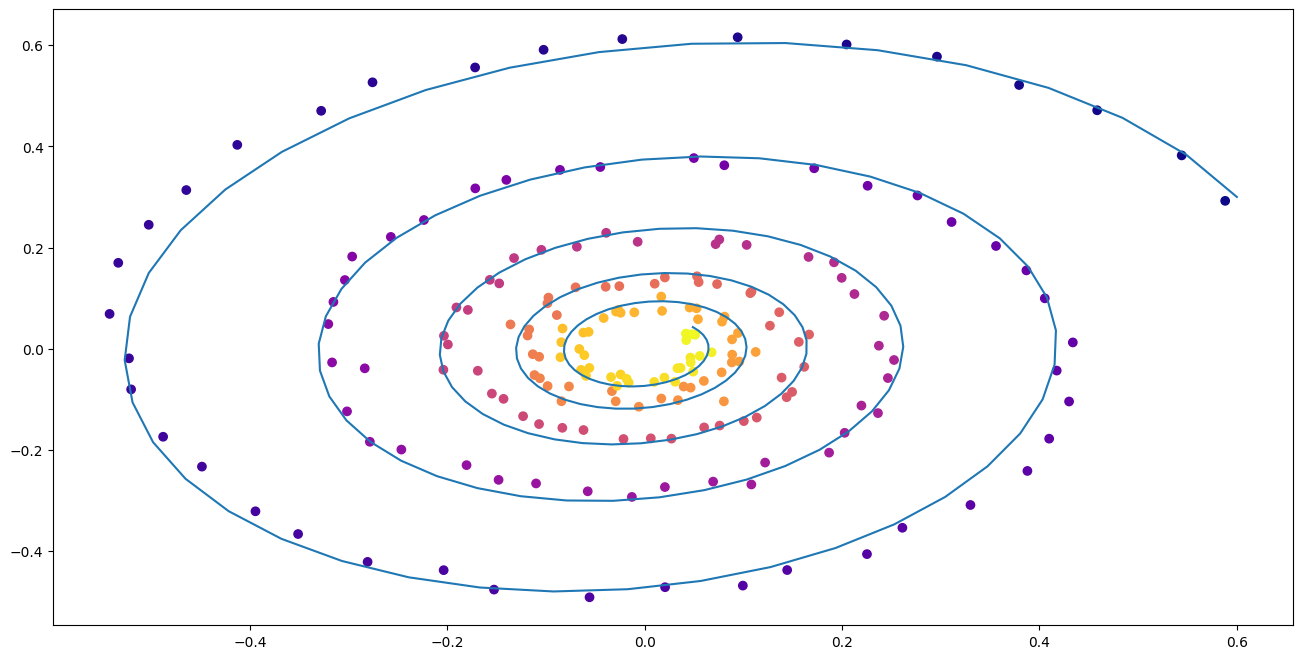

In [43]:
conduct_experiment(ode_true, ode_trained, 500, "linear")


Next, slighty more sophisticated dynamics.
Trained function here is MLP with one hidden layer.

In [62]:
class LinearODEF(ODEF):
    def __init__(self, W):
        super(LinearODEF, self).__init__()
        self.lin = nn.Linear(2, 2, bias=False)
        self.lin.weight = nn.Parameter(W)

    def forward(self, x, t):
        return self.lin(x)

Dynamics is simply given with a matrix.



In [63]:
class SpiralFunctionExample(LinearODEF):
    def __init__(self):
        super(SpiralFunctionExample, self).__init__(Tensor([[-0.1, -1.], [1., -0.1]]))

Initial random linear dynamics function to be optimized



In [64]:
class RandomLinearODEF(LinearODEF):
    def __init__(self):
        super(RandomLinearODEF, self).__init__(torch.randn(2, 2)/2.)

More sophisticated dynamics for creating trajectories



In [65]:

class TestODEF(ODEF):
    def __init__(self, A, B, x0):
        super(TestODEF, self).__init__()
        self.A = nn.Linear(2, 2, bias=False)
        self.A.weight = nn.Parameter(A)
        self.B = nn.Linear(2, 2, bias=False)
        self.B.weight = nn.Parameter(B)
        self.x0 = nn.Parameter(x0)

    def forward(self, x, t):
        xTx0 = torch.sum(x*self.x0, dim=1)
        dxdt = torch.sigmoid(xTx0) * self.A(x - self.x0) + torch.sigmoid(-xTx0) * self.B(x + self.x0)
        return dxdt

Dynamics function to be optimized is MLP

In [66]:
class NNODEF(ODEF):
    def __init__(self, in_dim, hid_dim, time_invariant=False):
        super(NNODEF, self).__init__()
        self.time_invariant = time_invariant

        if time_invariant:
            self.lin1 = nn.Linear(in_dim, hid_dim)
        else:
            self.lin1 = nn.Linear(in_dim+1, hid_dim)
        self.lin2 = nn.Linear(hid_dim, hid_dim)
        self.lin3 = nn.Linear(hid_dim, in_dim)
        self.elu = nn.ELU(inplace=True)

    def forward(self, x, t):
        if not self.time_invariant:
            x = torch.cat((x, t), dim=-1)

        h = self.elu(self.lin1(x))
        h = self.elu(self.lin2(h))
        out = self.lin3(h)
        return out

In [67]:
def to_np(x):
    return x.detach().cpu().numpy()

In [68]:
def plot_trajectories(obs=None, times=None, trajs=None, save=None, figsize=(16, 8)):
    plt.figure(figsize=figsize)
    if obs is not None:
        if times is None:
            times = [None] * len(obs)
        for o, t in zip(obs, times):
            o, t = to_np(o), to_np(t)
            for b_i in range(o.shape[1]):
                plt.scatter(o[:, b_i, 0], o[:, b_i, 1], c=t[:, b_i, 0], cmap=cm.plasma)

    if trajs is not None: 
        for z in trajs:
            z = to_np(z)
            plt.plot(z[:, 0, 0], z[:, 0, 1], lw=1.5)
        if save is not None:
            plt.savefig(save)
    plt.show()

In [69]:
def conduct_experiment(ode_true, ode_trained, n_steps, name, plot_freq=10):
    # Create data
    z0 = Variable(torch.Tensor([[0.6, 0.3]]))

    t_max = 6.29*5
    n_points = 200

    index_np = np.arange(0, n_points, 1, dtype=int)
    index_np = np.hstack([index_np[:, None]])
    times_np = np.linspace(0, t_max, num=n_points)
    times_np = np.hstack([times_np[:, None]])

    times = torch.from_numpy(times_np[:, :, None]).to(z0)
    obs = ode_true(z0, times, return_whole_sequence=True).detach()
    obs = obs + torch.randn_like(obs) * 0.01

    # Get trajectory of random timespan 
    min_delta_time = 1.0
    max_delta_time = 5.0
    max_points_num = 32
    def create_batch():
        t0 = np.random.uniform(0, t_max - max_delta_time)
        t1 = t0 + np.random.uniform(min_delta_time, max_delta_time)

        idx = sorted(np.random.permutation(index_np[(times_np > t0) & (times_np < t1)])[:max_points_num])

        obs_ = obs[idx]
        ts_ = times[idx]
        return obs_, ts_

    # Train Neural ODE
    optimizer = torch.optim.Adam(ode_trained.parameters(), lr=0.01)
    for i in range(n_steps):
        obs_, ts_ = create_batch()

        z_ = ode_trained(obs_[0], ts_, return_whole_sequence=True)
        loss = F.mse_loss(z_, obs_.detach())

        optimizer.zero_grad()
        loss.backward(retain_graph=True)
        optimizer.step()

        if i % plot_freq == 0:
            z_p = ode_trained(z0, times, return_whole_sequence=True)

            import os
            os.makedirs(f"figures/imgs/{name}", exist_ok=True)
            plot_trajectories(obs=[obs], times=[times], trajs=[z_p], save=f"figures/imgs/{name}/{i}.png")
            clear_output(wait=True)

In [70]:
ode_true = NeuralODE(SpiralFunctionExample())
ode_trained = NeuralODE(RandomLinearODEF())

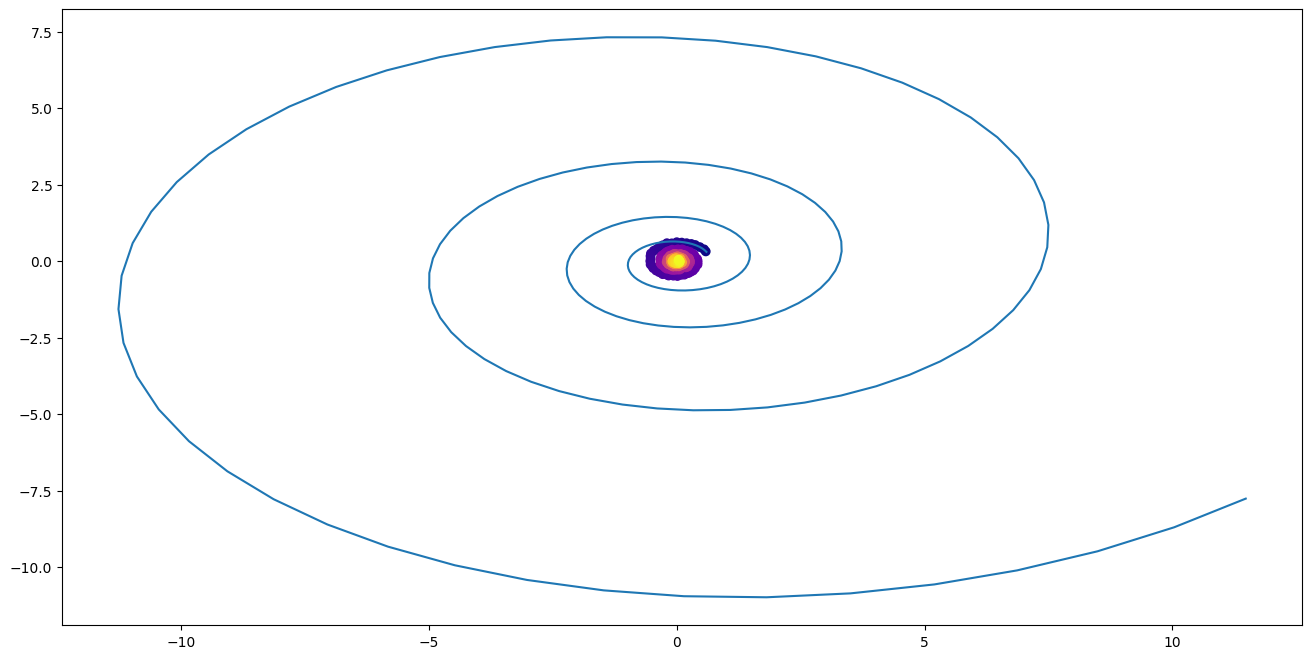

In [71]:
conduct_experiment(ode_true, ode_trained, 500, "linear")


In [72]:
func = TestODEF(Tensor([[-0.1, -0.5], [0.5, -0.1]]), Tensor([[0.2, 1.], [-1, 0.2]]), Tensor([[-1., 0.]]))
ode_true = NeuralODE(func)

func = NNODEF(2, 16, time_invariant=True)
ode_trained = NeuralODE(func)

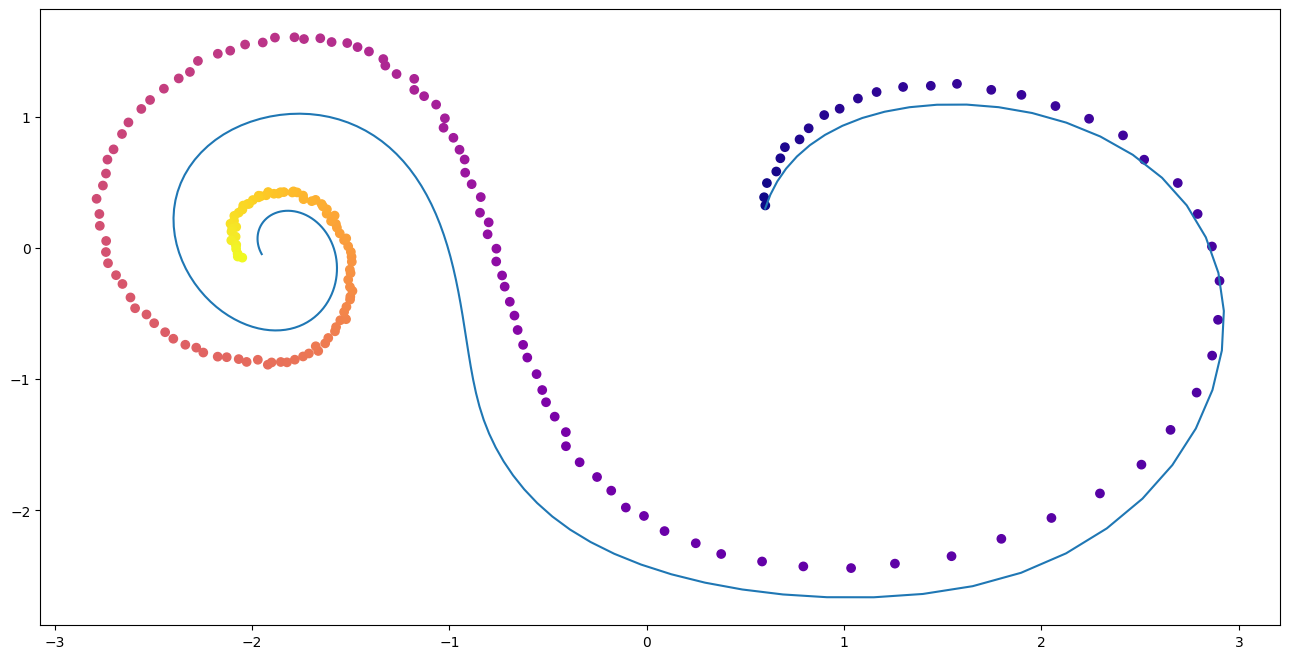

In [73]:
conduct_experiment(ode_true, ode_trained, 3000, "comp", plot_freq=30)


As one can see, Neural ODEs are pretty successful in approximating dynamics.

# Example 2: Neural ODE Timeseries Example using TorchDiffEq

In [75]:
import time
import os
import math

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torchdiffeq import odeint


# Vector field f_theta(t, y)

In [77]:
class Func(nn.Module):
    def __init__(self, data_size, width_size, depth):
        super().__init__()
        self.out_scale = nn.Parameter(torch.ones(1))

        layers = []
        in_dim = data_size
        for _ in range(depth):
            layers += [nn.Linear(in_dim, width_size), nn.Softplus()]
            in_dim = width_size
        layers += [nn.Linear(in_dim, data_size), nn.Tanh()]
        self.mlp = nn.Sequential(*layers)

    def forward(self, t, y):
        # t is a scalar tensor; y has shape (batch, data_size)
        return self.out_scale * self.mlp(y)


# NeuralODE wrapper

In [92]:

class NeuralODE(nn.Module):
    def __init__(self, data_size, width_size, depth):
        super().__init__()
        self.func = Func(data_size, width_size, depth)

    def forward(self, ts, y0):
        # ts  : (T,)
        # y0  : (batch, data_size)
        # returns (T, batch, data_size)
        return odeint(self.func, y0, ts, rtol=1e-3, atol=1e-6, method="dopri5")

# Toy nonlinear oscillator dataset
x' = [x1/(1+x1), -x0/(1+x0)]  (element-wise)

In [93]:
def _get_single_trajectory(ts, y0_np):
    """Integrate one trajectory with simple RK4 (no extra deps)."""
    y = y0_np.copy()
    dt = ts[1] - ts[0]
    traj = [y.copy()]

    def f(y_):
        x = y_ / (1.0 + y_)
        return np.array([x[1], -x[0]])

    for _ in range(len(ts) - 1):
        k1 = f(y)
        k2 = f(y + 0.5 * dt * k1)
        k3 = f(y + 0.5 * dt * k2)
        k4 = f(y + dt * k3)
        y = y + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        traj.append(y.copy())

    return np.stack(traj, axis=0)   # (T, 2)

In [94]:
def get_data(dataset_size, seed=0):
    rng = np.random.default_rng(seed)
    ts_np = np.linspace(0, 10, 100)
    y0s = rng.uniform(-0.6, 1.0, size=(dataset_size, 2))
    ys = np.stack([_get_single_trajectory(ts_np, y0) for y0 in y0s], axis=0)
    # ys shape: (dataset_size, T, 2)
    ts = torch.tensor(ts_np, dtype=torch.float32)
    ys = torch.tensor(ys, dtype=torch.float32)
    return ts, ys

In [95]:
def dataloader(ys, batch_size, seed=42):
    rng = np.random.default_rng(seed)
    n = ys.shape[0]
    while True:
        perm = rng.permutation(n)
        start = 0
        while start + batch_size <= n:
            idx = perm[start : start + batch_size]
            yield ys[idx]
            start += batch_size


In [96]:
def plot_training_curves(loss_history, save_path):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(loss_history, color="#e63946", linewidth=1.5)
    ax.set_xlabel("Step", fontsize=12)
    ax.set_ylabel("MSE Loss", fontsize=12)
    ax.set_title("Training Loss", fontsize=14)
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    fig.show()
    print(f"Saved training curve -> {save_path}")

In [97]:
def plot_trajectory_comparison(ts, ys, model, n_samples=4, save_path="comparison.png"):
        """
        For n_samples trajectories: plot real vs predicted in both
        time-series form and phase-portrait form.
        """
        model.eval()
        with torch.no_grad():
                y0_batch = ys[:n_samples, 0, :]       # (n_samples, 2)
                pred = model(ts, y0_batch)             # (T, n_samples, 2)
                pred = pred.permute(1, 0, 2).cpu()     # (n_samples, T, 2)

        ts_np = ts.cpu().numpy()
        ys_np = ys[:n_samples].cpu().numpy()
        pred_np = pred.numpy()

        colors_real = ["#023e8a", "#0077b6", "#0096c7", "#00b4d8"]
        colors_pred = ["#d62828", "#f77f00", "#fcbf49", "#eae2b7"]

        fig = plt.figure(figsize=(16, 4 * n_samples))
        gs = gridspec.GridSpec(n_samples, 3, figure=fig, hspace=0.45, wspace=0.35)

        for i in range(n_samples):
                # -- channel 0 over time --
                ax0 = fig.add_subplot(gs[i, 0])
                ax0.plot(ts_np, ys_np[i, :, 0], color=colors_real[i], lw=2, label="real")
                ax0.plot(ts_np, pred_np[i, :, 0], color=colors_pred[i], lw=1.5,
                        linestyle="--", label="model")
                ax0.set_title(f"Sample {i+1}  --  y[0] vs t", fontsize=10)
                ax0.legend(fontsize=8)
                ax0.grid(True, alpha=0.25)

                # -- channel 1 over time --
                ax1 = fig.add_subplot(gs[i, 1])
                ax1.plot(ts_np, ys_np[i, :, 1], color=colors_real[i], lw=2, label="real")
                ax1.plot(ts_np, pred_np[i, :, 1], color=colors_pred[i], lw=1.5,
                        linestyle="--", label="model")
                ax1.set_title(f"Sample {i+1}  --  y[1] vs t", fontsize=10)
                ax1.legend(fontsize=8)
                ax1.grid(True, alpha=0.25)

                # -- phase portrait --
                ax2 = fig.add_subplot(gs[i, 2])
                ax2.plot(ys_np[i, :, 0], ys_np[i, :, 1], color=colors_real[i],
                        lw=2, label="real")
                ax2.plot(pred_np[i, :, 0], pred_np[i, :, 1], color=colors_pred[i],
                        lw=1.5, linestyle="--", label="model")
                ax2.scatter(ys_np[i, 0, 0], ys_np[i, 0, 1], color=colors_real[i],
                        zorder=5, s=40)
                ax2.set_title(f"Sample {i+1}  --  phase portrait", fontsize=10)
                ax2.legend(fontsize=8)
                ax2.set_xlabel("y[0]", fontsize=9)
                ax2.set_ylabel("y[1]", fontsize=9)
                ax2.grid(True, alpha=0.25)

        fig.suptitle("Neural ODE  --  Real vs Model Trajectories", fontsize=15, y=1.01)
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        fig.show()
        print(f"Saved trajectory comparison -> {save_path}")

In [98]:
def plot_error_heatmap(ts, ys, model, save_path="error_heatmap.png"):
    """
    Absolute error heatmap: x-axis = time, y-axis = sample index.
    Useful to see where in time the model drifts.
    """
    model.eval()
    n = min(64, ys.shape[0])
    with torch.no_grad():
        y0_batch = ys[:n, 0, :]
        pred = model(ts, y0_batch).permute(1, 0, 2).cpu()

    err = (pred - ys[:n].cpu()).abs().mean(dim=-1).numpy()   # (n, T)

    fig, ax = plt.subplots(figsize=(12, 5))
    im = ax.imshow(err, aspect="auto", cmap="inferno",
                extent=[ts[0].item(), ts[-1].item(), n, 0])
    fig.colorbar(im, ax=ax, label="Mean absolute error")
    ax.set_xlabel("Time", fontsize=12)
    ax.set_ylabel("Sample index", fontsize=12)
    ax.set_title("Prediction Error Over Time", fontsize=14)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    print(f"Saved error heatmap -> {save_path}")

Using device: cuda
Model parameters: 4483

--- Phase 1/2 | seq length=10 | steps=500 ---
  step    0  loss=0.081534  time=0.039s
  step  100  loss=0.015311  time=0.037s
  step  200  loss=0.007121  time=0.037s
  step  300  loss=0.004012  time=0.036s
  step  400  loss=0.009869  time=0.037s
  step  499  loss=0.002647  time=0.036s

--- Phase 2/2 | seq length=100 | steps=500 ---
  step    0  loss=0.056304  time=0.207s
  step  100  loss=0.027009  time=0.221s
  step  200  loss=0.023185  time=0.176s
  step  300  loss=0.014915  time=0.184s
  step  400  loss=0.015518  time=0.194s
  step  499  loss=0.007601  time=0.218s
Saved training curve -> neural_ode_outputs/loss_curve.png


/tmp/ipykernel_350525/3995999304.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_350525/642188964.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Saved trajectory comparison -> neural_ode_outputs/trajectories.png
Saved error heatmap -> neural_ode_outputs/error_heatmap.png


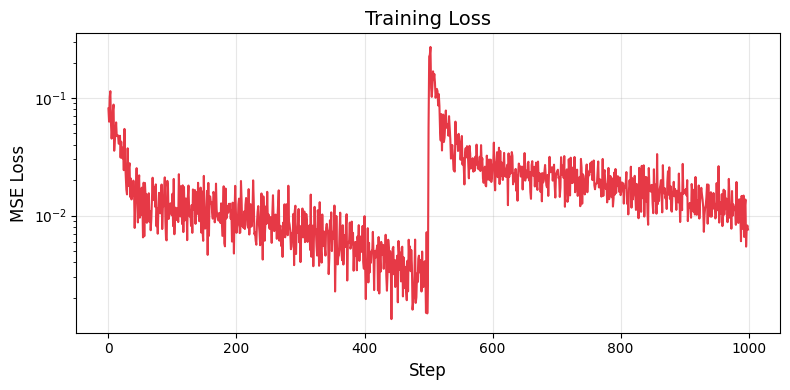

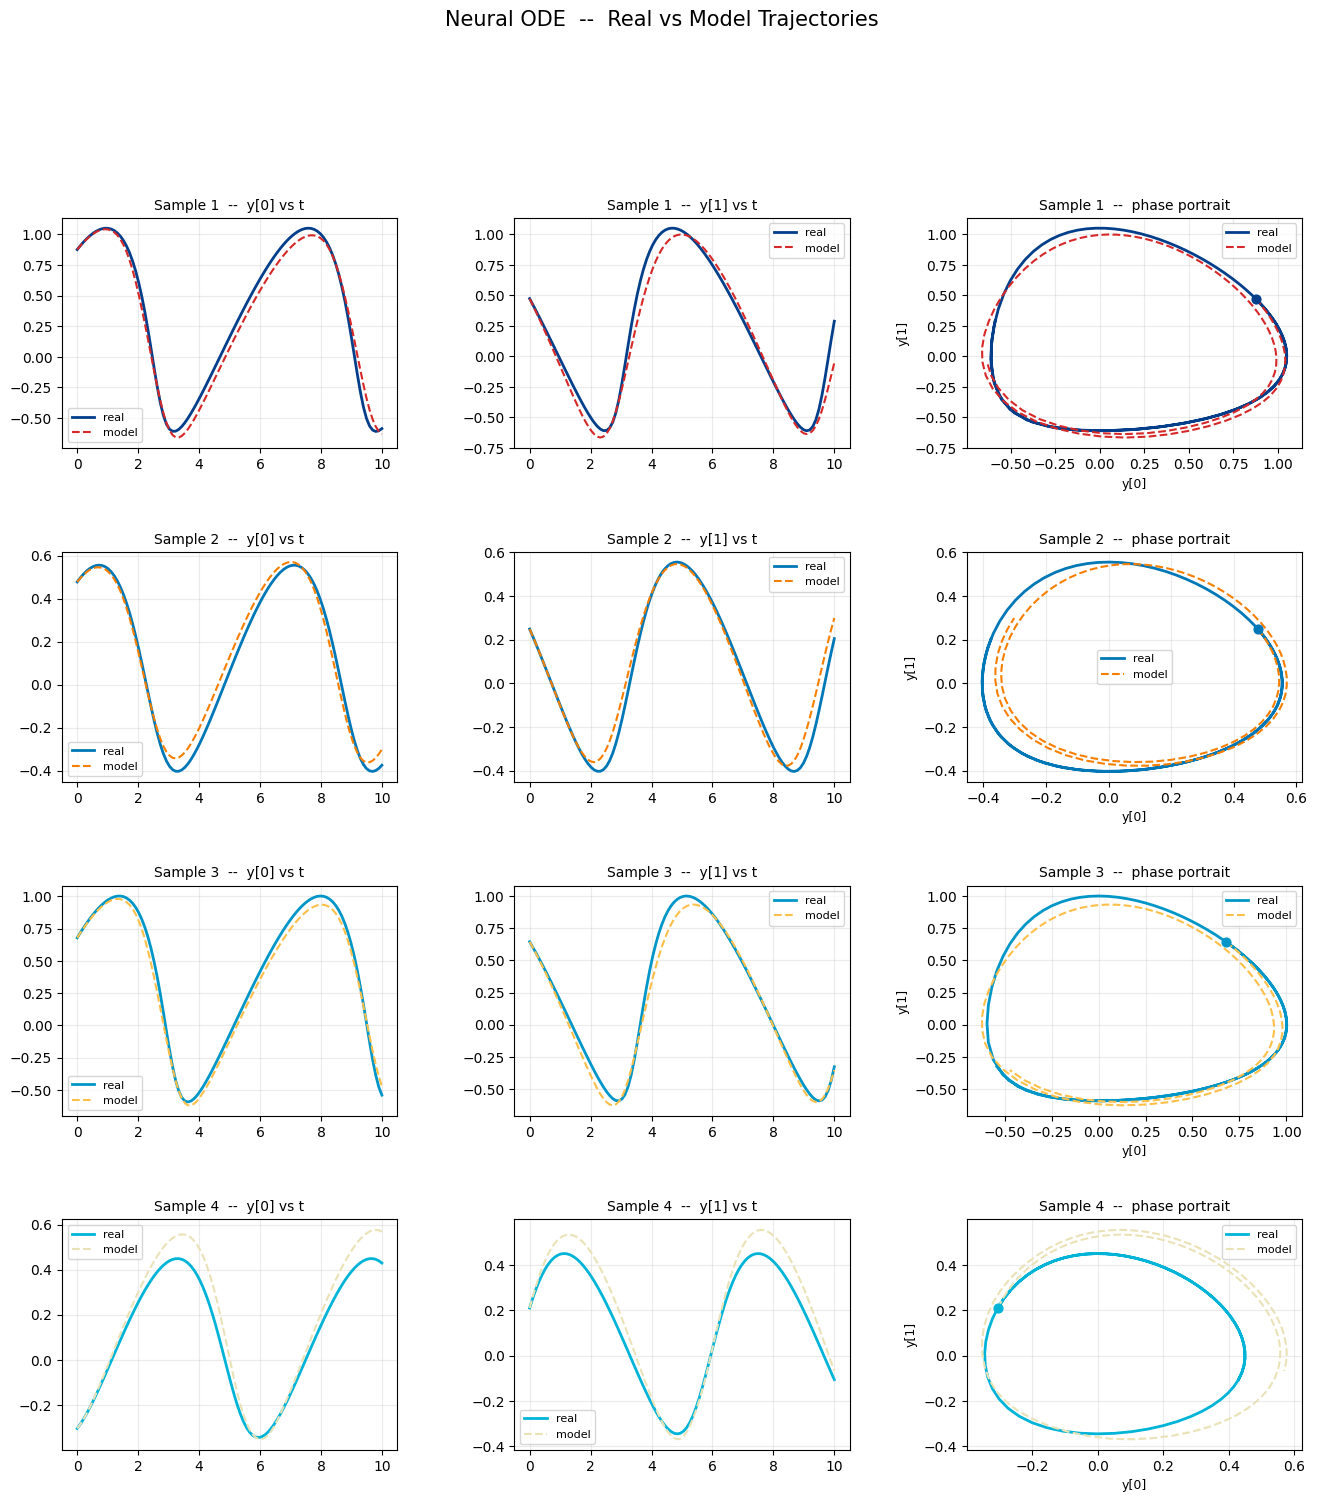

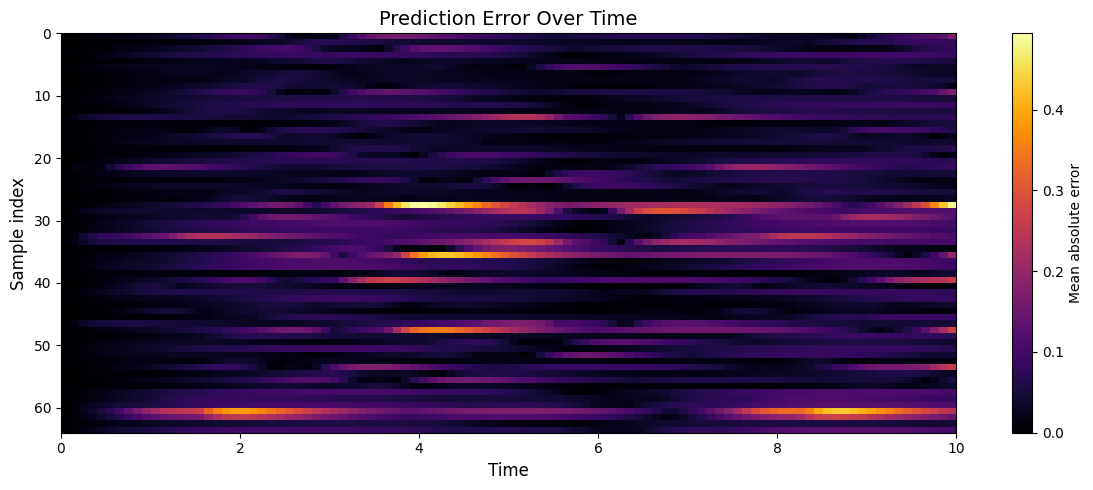

In [99]:

dataset_size=256
batch_size=32
lr=3e-3
steps_strategy=(500, 500)
length_strategy=(0.1, 1.0)
width_size=64
depth=2
seed=5678
print_every=100

save_dir="neural_ode_outputs"

os.makedirs(save_dir, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Data
ts, ys = get_data(dataset_size, seed=seed)
ts = ts.to(device)
ys = ys.to(device)
_, length_size, data_size = ys.shape

# Model
model = NeuralODE(data_size, width_size, depth).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params}")

loss_history = []

# Curriculum: train on short sequences first, then full
for phase, (steps, length) in enumerate(zip(steps_strategy, length_strategy)):
    T = int(length_size * length)
    ts_phase = ts[:T]
    ys_phase = ys[:, :T, :]

    optimizer = optim.AdamW(model.parameters(), lr=lr)
    loader = dataloader(ys_phase, batch_size, seed=seed + phase)

    print(f"\n--- Phase {phase+1}/{len(steps_strategy)} | "
        f"seq length={T} | steps={steps} ---")

    for step, yi in zip(range(steps), loader):
        t0 = time.time()
        model.train()

        yi = yi.to(device)           # (batch, T, 2)
        y0 = yi[:, 0, :]             # (batch, 2)

        pred = model(ts_phase, y0)   # (T, batch, 2)
        pred = pred.permute(1, 0, 2) # (batch, T, 2)

        loss = ((pred - yi) ** 2).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_val = loss.item()
        loss_history.append(loss_val)

        if step % print_every == 0 or step == steps - 1:
            elapsed = time.time() - t0
            print(f"  step {step:4d}  loss={loss_val:.6f}  "
                f"time={elapsed:.3f}s")

# Visualizations
plot_training_curves(
    loss_history,
    save_path=os.path.join(save_dir, "loss_curve.png")
)
plot_trajectory_comparison(
    ts, ys, model, n_samples=4,
    save_path=os.path.join(save_dir, "trajectories.png")
)
plot_error_heatmap(
    ts, ys, model,
    save_path=os.path.join(save_dir, "error_heatmap.png")
)

